#Data Scientists Project

Research Question:  
  **How do nuclear energy capacity trends relate to policy changes within the United States?**



Context of Data
*   NUETSUS = Nuclear Share of Electricity Net Generation
*   Measures what % of total U.S. electricity came from nuclear energy (uranium) in a given year


Goals
*   Analyze how uranium enrichment changed over time & external factors






In [1]:
import pandas as pd

#creating dataframe of the cleaned dataset
data = pd.read_csv('../data/NUETSUS.csv')
data.head()



,MSN,YYYYMM,Value,Column_Order,Description,Unit
0,NUETSUS,195713,0.0,4,Nuclear Share of Electricity Net Generation,Percent
1,NUETSUS,195813,0.0,4,Nuclear Share of Electricity Net Generation,Percent
2,NUETSUS,195913,0.0,4,Nuclear Share of Electricity Net Generation,Percent
3,NUETSUS,196013,0.1,4,Nuclear Share of Electricity Net Generation,Percent
4,NUETSUS,196113,0.2,4,Nuclear Share of Electricity Net Generation,Percent


In [2]:
#getting insights about dataset

data.describe()

,YYYYMM,Value,Column_Order
count,705.000000,705.000000,705.0
mean,199828.838298,16.861418,4.0
std,1599.511999,4.740315,0.0
min,195713.000000,0.000000,4.0
25%,198505.000000,15.000000,4.0
50%,199812.000000,18.700000,4.0
75%,201206.000000,20.000000,4.0
max,202513.000000,22.900000,4.0


Building a visualization of what % of energy in the US was nuclear for each year from 1957-2025


In [3]:
#creating a new data frame only with annual values, since the original contains monthly & yearly

#in the dataset, 13 is used for the annual %
year_data = data[data["YYYYMM"] % 100 == 13].copy()
year_data["Year"] = year_data["YYYYMM"] // 100
year_data.head()





,MSN,YYYYMM,Value,Column_Order,Description,Unit,Year
0,NUETSUS,195713,0.0,4,Nuclear Share of Electricity Net Generation,Percent,1957
1,NUETSUS,195813,0.0,4,Nuclear Share of Electricity Net Generation,Percent,1958
2,NUETSUS,195913,0.0,4,Nuclear Share of Electricity Net Generation,Percent,1959
3,NUETSUS,196013,0.1,4,Nuclear Share of Electricity Net Generation,Percent,1960
4,NUETSUS,196113,0.2,4,Nuclear Share of Electricity Net Generation,Percent,1961


Text(0.5, 1.0, 'Nuclear Energy % Over Time')

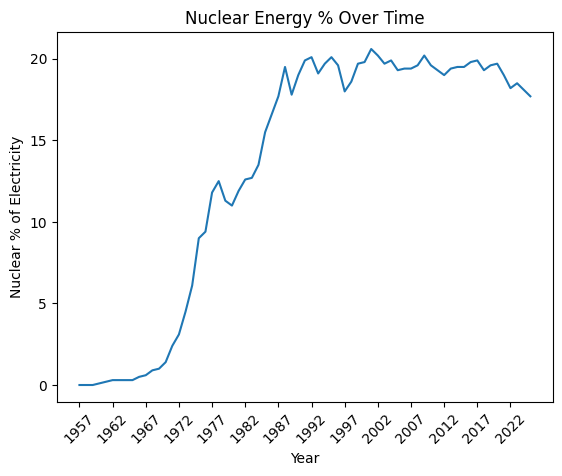

In [4]:
#plotting the % value per year from 1957-2025

import matplotlib.pyplot as plt

plt.plot(year_data["Year"], year_data["Value"])
plt.xticks(year_data["Year"][::5], rotation=45)

plt.xlabel("Year")
plt.ylabel("Nuclear % of Electricity")
plt.title("Nuclear Energy % Over Time")



Text(0.5, 1.0, 'Nuclear Energy % Over Time per Month')

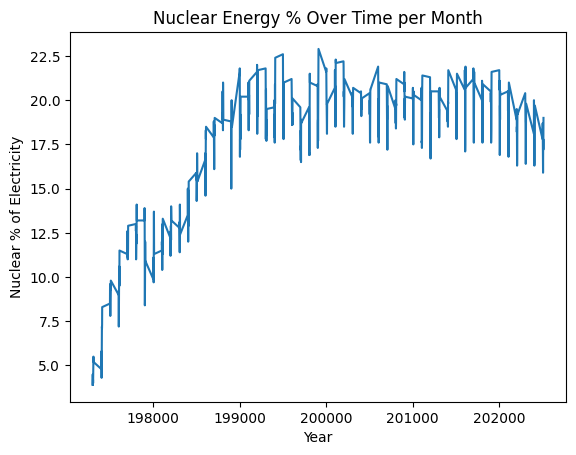

In [5]:
#plotting % nuclear energy but with each month plotted, not just annually

#creating month dataframe
month_data = data[data["YYYYMM"] % 100 != 13]
plt.plot(month_data["YYYYMM"], month_data["Value"])

plt.xlabel("Year")
plt.ylabel("Nuclear % of Electricity")
plt.title("Nuclear Energy % Over Time per Month")


After observing the share of nuclear energy in the US on an annual scale and monthly scale, we have discovered that the value is very volitile with sharp spikes and drops. It is interesting that there are sharp spikes regardless of the monthly and the yearly plot, this is indicating the volitility of nuclear usage and that more analysis should be done zooming in on certain periods.

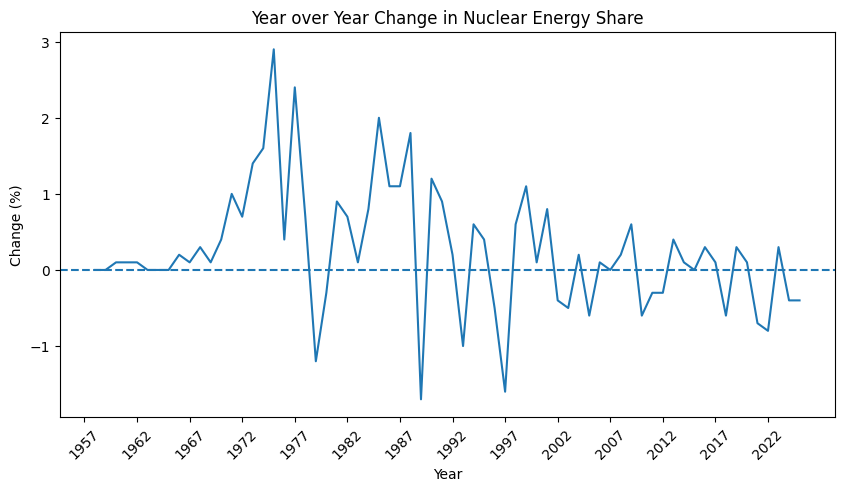

In [6]:
#using diff() to calculate the difference between a value and the one before it

#getting the year over year change
year_data["yoy diff"] = year_data["Value"].diff()

plt.figure(figsize=(10,5))
plt.plot(year_data["Year"], year_data["yoy diff"])
plt.xticks(year_data["Year"][::5], rotation=45)
plt.axhline(0, linestyle='--')
plt.title("Year over Year Change in Nuclear Energy Share")
plt.xlabel("Year")
plt.ylabel("Change (%)")
plt.show()

This proves the volitility of the nuclear change. We can use this data to zoom in closer to certain periods with the biggest jumps.

In [7]:
#finding the lowest drops & highest spikes

lowest_drops = year_data.nsmallest(10, "yoy diff")
print("Biggest Drops:")
print(lowest_drops[["Year", "yoy diff"]])

highest_spikes = year_data.nlargest(10, "yoy diff")
print("\nBiggest Growth:")
print(highest_spikes[["Year", "yoy diff"]])


Biggest Drops:
     Year  yoy diff
236  1989      -1.7
340  1997      -1.6
106  1979      -1.2
288  1993      -1.0
665  2022      -0.8
652  2021      -0.7
444  2005      -0.6
509  2010      -0.6
613  2018      -0.6
327  1996      -0.5

Biggest Growth:
     Year  yoy diff
54   1975       2.9
80   1977       2.4
184  1985       2.0
223  1988       1.8
41   1974       1.6
28   1973       1.4
249  1990       1.2
197  1986       1.1
210  1987       1.1
366  1999       1.1


By listing the biggest changes (pos & neg), we can now see which each expierenced the largest drops and spikes. Using this information, combined with the original Time V Value plot, we can now pick specific windows of time to zoom in on and further investigate.

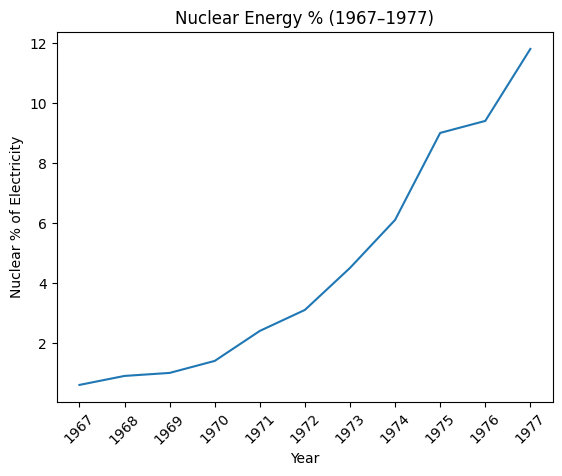

In [8]:
subset = year_data[(year_data["Year"] >= 1967) & (year_data["Year"] <= 1977)]

plt.plot(subset["Year"], subset["Value"])
plt.xticks(subset["Year"], rotation=45)

plt.xlabel("Year")
plt.ylabel("Nuclear % of Electricity")
plt.title("Nuclear Energy % (1967–1977)")
plt.show()

Exploring the first "zoomed in time window". Here, we chose to look deeper in to the years of 1967 to 1977, as this period expierenced a sharp spike in nuclear usuage in the US. 1967 started with 0.6% and in 1977 it was 11.8% usage. This showcases a lot of growth during this period.

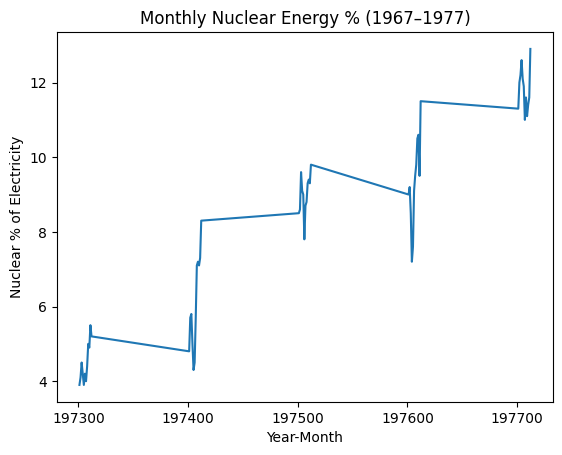

In [9]:
month_subset = month_data[
    (month_data["YYYYMM"] // 100 >= 1967) &
    (month_data["YYYYMM"] // 100 <= 1977)]


plt.plot(month_subset["YYYYMM"], month_subset["Value"])

plt.xlabel("Year-Month")
plt.ylabel("Nuclear % of Electricity")
plt.title("Monthly Nuclear Energy % (1967–1977)")

plt.show()


### Key Historical Events (1967–1977)

- **Cold War Nuclear Expansion (1960s–1970s):** Heightened U.S.–Soviet competition led to large investments in nuclear technology, including civilian nuclear energy infrastructure.

- **Vietnam War Escalation (1964–1968):** The U.S. increased military involvement to contain communism, reinforcing the importance of energy security and technological dominance.

- **Soviet Invasion of Czechoslovakia (1968):** The suppression of the Prague Spring intensified Cold War tensions, contributing to continued U.S. investment in strategic and technological capabilities, including nuclear.

- **Apollo 11 Moon Landing (1969):** Marked U.S. technological superiority during the Cold War, reflecting broader investments in advanced science and engineering, including nuclear energy.

- **National Environmental Policy Act (1970):** Introduced environmental regulations requiring impact assessments, which began influencing nuclear power plant development and approval processes.

- **Formation of the Environmental Protection Agency (1970):** Increased federal oversight on environmental and safety standards, affecting nuclear energy expansion.

- **Détente and SALT I (1972):** Agreements between the U.S. and USSR to limit nuclear weapons reduced military tensions but did not halt civilian nuclear energy development.

- **1973 Oil Crisis:** OPEC oil embargo caused a sharp rise in oil prices, pushing the U.S. to seek energy independence and accelerating investment in nuclear power.

- **Energy Reorganization Act (1974):** Split the Atomic Energy Commission into the Nuclear Regulatory Commission (NRC) and ERDA, increasing regulatory oversight of nuclear power.

- **Vietnam War End (1973–1975):** U.S. withdrawal marked a shift in geopolitical focus, while domestic energy concerns (like nuclear power) became more prominent.

- **Operation Condor (1975):** U.S.-backed efforts to contain communism in Latin America reflected broader Cold War priorities influencing technological and energy strategies.

- **Peak Nuclear Construction Era (Early–Mid 1970s):** Dozens of nuclear power plants were ordered and built in response to rising energy demand and supportive government policies.

- **Energy Policy and Conservation Act (1975):** Promoted energy efficiency and diversification, indirectly supporting nuclear as an alternative to fossil fuels.




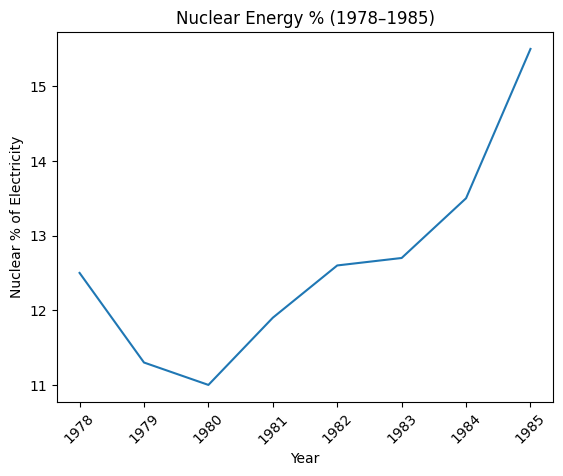

In [10]:
subset = year_data[(year_data["Year"] >= 1978) & (year_data["Year"] <= 1985)]

plt.plot(subset["Year"], subset["Value"])
plt.xticks(subset["Year"], rotation=45)

plt.xlabel("Year")
plt.ylabel("Nuclear % of Electricity")
plt.title("Nuclear Energy % (1978–1985)")
plt.show()

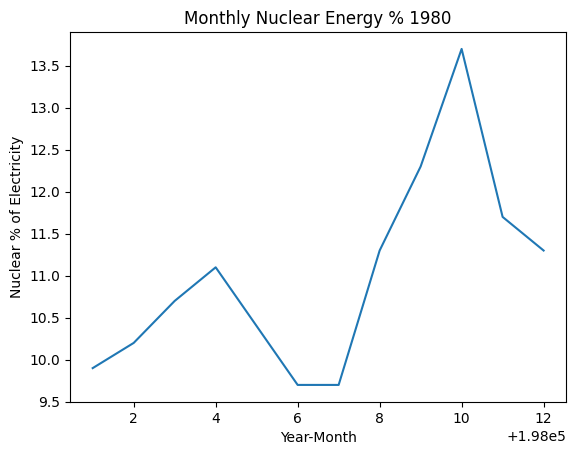

In [11]:
eighty_subset = month_data[
    (month_data["YYYYMM"] // 100 >= 1980) &
    (month_data["YYYYMM"] // 100 <= 1980)]


plt.plot(eighty_subset["YYYYMM"], eighty_subset["Value"])

plt.xlabel("Year-Month")
plt.ylabel("Nuclear % of Electricity")
plt.title("Monthly Nuclear Energy % 1980")

plt.show()

Now, comparing value data with policy data, by merging policy dataset into their corresponding years.

In [12]:
policy_data = pd.read_csv('../data/policy.csv')
y_data = year_data.copy()

policy_data.head()



,Year,Event_Name,Event_Type,Policy_Indicator,Description,Source
0,1957,Price-Anderson Nuclear Industries Act,Pro-Nuclear Policy,1,Limited private liability for nuclear accident...,NRC / U.S. Congress
1,1973,Yom Kippur War / Arab Oil Embargo,War / Energy Security Shock,1,Oil supply disruption increased interest in do...,DOE History Timeline
2,1974,Energy Reorganization Act,Regulation,0,Abolished the AEC and created the NRC and ERDA...,NRC / U.S. Congress
3,1979,Three Mile Island Accident,Accident,-1,Partial core meltdown sharply reduced public c...,NRC
4,1982,Nuclear Waste Policy Act,Regulation,-1,Created the federal repository framework but a...,DOE / U.S. Congress


In [13]:
#merging the two datasets
#in any years where a policy occurred, it will be added to that record

yearly_policy_data = pd.merge(y_data, policy_data, on="Year", how="left")
yearly_policy_data.head(20)

,MSN,YYYYMM,Value,Column_Order,Description_x,Unit,Year,yoy diff,Event_Name,Event_Type,Policy_Indicator,Description_y,Source
0,NUETSUS,195713,0.0,4,Nuclear Share of Electricity Net Generation,Percent,1957,NaN,Price-Anderson Nuclear Industries Act,Pro-Nuclear Policy,1.0,Limited private liability for nuclear accident...,NRC / U.S. Congress
1,NUETSUS,195813,0.0,4,Nuclear Share of Electricity Net Generation,Percent,1958,0.0,NaN,NaN,NaN,NaN,NaN
2,NUETSUS,195913,0.0,4,Nuclear Share of Electricity Net Generation,Percent,1959,0.0,NaN,NaN,NaN,NaN,NaN
3,NUETSUS,196013,0.1,4,Nuclear Share of Electricity Net Generation,Percent,1960,0.1,NaN,NaN,NaN,NaN,NaN
4,NUETSUS,196113,0.2,4,Nuclear Share of Electricity Net Generation,Percent,1961,0.1,NaN,NaN,NaN,NaN,NaN
5,NUETSUS,196213,0.3,4,Nuclear Share of Electricity Net Generation,Percent,1962,0.1,NaN,NaN,NaN,NaN,NaN
6,NUETSUS,196313,0.3,4,Nuclear Share of Electricity Net Generation,Percent,1963,0.0,NaN,NaN,NaN,NaN,NaN
7,NUETSUS,196413,0.3,4,Nuclear Share of Electricity Net Generation,Percent,1964,0.0,NaN,NaN,NaN,NaN,NaN
8,NUETSUS,196513,0.3,4,Nuclear Share of Electricity Net Generation,Percent,1965,0.0,NaN,NaN,NaN,NaN,NaN
9,NUETSUS,196613,0.5,4,Nuclear Share of Electricity Net Generation,Percent,1966,0.2,NaN,NaN,NaN,NaN,NaN


Now, handling NaN's in the joint dataset. Years where no significant political event with nuclear impact occurred Event will be "None" and the Policy Indicator will be 0.

In [14]:
yearly_policy_data["Event_Name"] = yearly_policy_data["Event_Name"].fillna("None")
yearly_policy_data["Event_Type"] = yearly_policy_data["Event_Name"].fillna("None")
yearly_policy_data["Policy_Indicator"] = yearly_policy_data["Policy_Indicator"].fillna(0)

#drop irrelevant
yearly_policy_data = yearly_policy_data.drop(columns=["Description_x", "Unit", "Description_y", "Column_Order", "YYYYMM", "Source"])
yearly_policy_data.head(20)

,MSN,Value,Year,yoy diff,Event_Name,Event_Type,Policy_Indicator
0,NUETSUS,0.0,1957,NaN,Price-Anderson Nuclear Industries Act,Price-Anderson Nuclear Industries Act,1.0
1,NUETSUS,0.0,1958,0.0,None,None,0.0
2,NUETSUS,0.0,1959,0.0,None,None,0.0
3,NUETSUS,0.1,1960,0.1,None,None,0.0
4,NUETSUS,0.2,1961,0.1,None,None,0.0
5,NUETSUS,0.3,1962,0.1,None,None,0.0
6,NUETSUS,0.3,1963,0.0,None,None,0.0
7,NUETSUS,0.3,1964,0.0,None,None,0.0
8,NUETSUS,0.3,1965,0.0,None,None,0.0
9,NUETSUS,0.5,1966,0.2,None,None,0.0


In [15]:
yearly_policy_data["cumulative_policy"] = yearly_policy_data["Policy_Indicator"].cumsum()
yearly_policy_data.head(20)
print(yearly_policy_data["cumulative_policy"])

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
     ... 
64    3.0
65    4.0
66    5.0
67    6.0
68    6.0
Name: cumulative_policy, Length: 69, dtype: float64


The cumulative policy value ends at +6, indicating that pro-nuclear policies slightly outweigh negative events over time. However, the relatively small magnitude suggests that nuclear policy in the U.S. has experienced a mixed and fluctuating trajectory rather than consistent support.

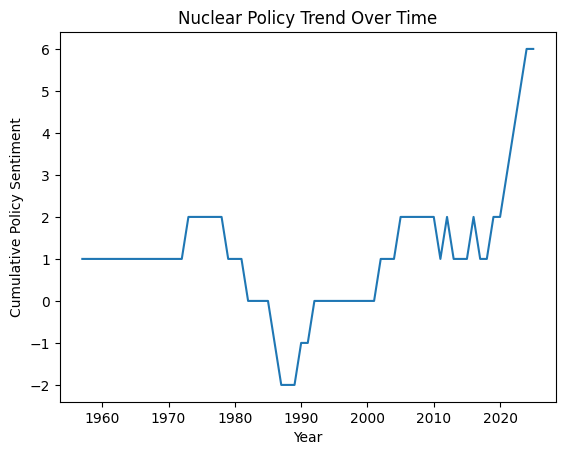

In [16]:
import matplotlib.pyplot as plt

plt.plot(yearly_policy_data["Year"], yearly_policy_data["cumulative_policy"])
plt.xlabel("Year")
plt.ylabel("Cumulative Policy Sentiment")
plt.title("Nuclear Policy Trend Over Time")
plt.show()

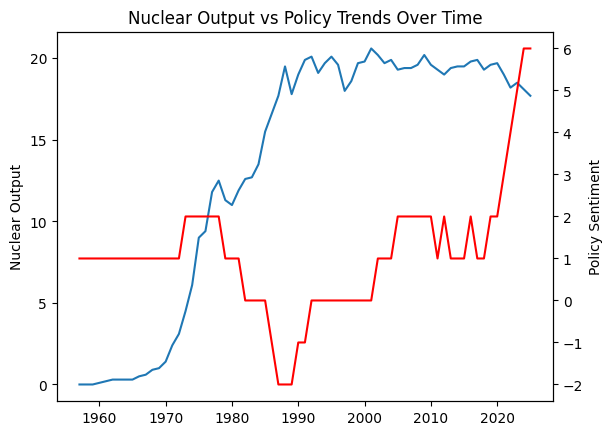

In [17]:

fig, ax1 = plt.subplots()

ax1.plot(yearly_policy_data["Year"], yearly_policy_data["Value"])
ax1.set_ylabel("Nuclear Output")

ax2 = ax1.twinx()
ax2.plot(yearly_policy_data["Year"], yearly_policy_data["cumulative_policy"], color="red")
ax2.set_ylabel("Policy Sentiment")

plt.title("Nuclear Output vs Policy Trends Over Time")
plt.show()

Although policy sentiment declines between 1980 and 1990, nuclear output continues to rise due to long construction timelines and previously approved projects. However, this negative sentiment is reflected in the stagnation of nuclear output in later years, indicating that policy impacts long-term growth rather than immediate production.

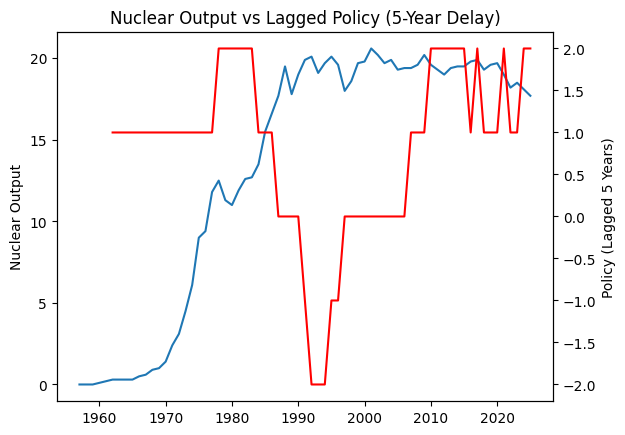

In [18]:
import matplotlib.pyplot as plt

yearly_policy_data["policy_lag_5"] = yearly_policy_data["cumulative_policy"].shift(5)
fig, ax1 = plt.subplots()

# Nuclear output (left axis)
ax1.plot(yearly_policy_data["Year"], yearly_policy_data["Value"])
ax1.set_ylabel("Nuclear Output")

# Lagged policy (right axis)
ax2 = ax1.twinx()
ax2.plot(yearly_policy_data["Year"], yearly_policy_data["policy_lag_5"], color="red")
ax2.set_ylabel("Policy (Lagged 5 Years)")

plt.title("Nuclear Output vs Lagged Policy (5-Year Delay)")
plt.show()

Here, we're testing that theory by shifting the policy cumulations by 5 years and seeing that when nuclear policy sentiment declines, the nuclear output flattens. This is evident in the period around 1990.

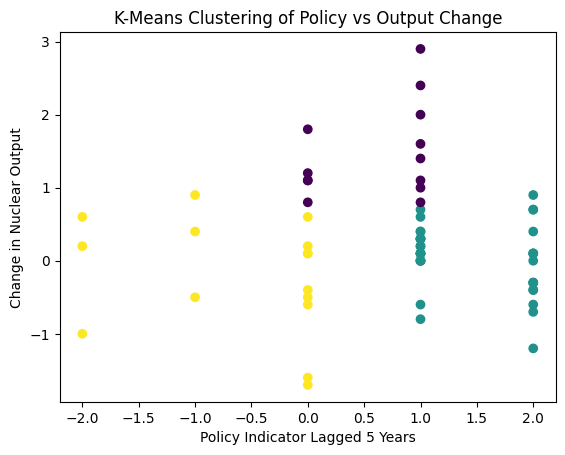

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# drop NaNs (important)
kmeans_df = yearly_policy_data[["policy_lag_5", "yoy diff"]].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(kmeans_df)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_df["cluster"] = kmeans.fit_predict(scaled_data)

import matplotlib.pyplot as plt

plt.scatter(
    kmeans_df["policy_lag_5"],
    kmeans_df["yoy diff"],
    c=kmeans_df["cluster"]
)

plt.xlabel("Policy Indicator Lagged 5 Years")
plt.ylabel("Change in Nuclear Output")
plt.title("K-Means Clustering of Policy vs Output Change")
plt.show()